In [14]:
#############################################
#  Group 1
#  Saba Gebru
#  Shuaiqi Xu
#  Zhengyuan Xie
#  Emannuel Matthews
##############################################

In [15]:
# 1. Load libraries
# Import packages needed for data analysis, visualization, and ML.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [16]:
# 2. Load dataset
# Load image features and product summary sheets.

file_path = "pet_cv_dataset_full.xlsx"

df = pd.read_excel(file_path, sheet_name="images_cv_features")
df_prod = pd.read_excel(file_path, sheet_name="product_summary")

df.head()

,row_id,asin,brand,product_name,category,performance_tier,known_rating,known_reviews,known_price_usd,known_bsr_pets,...,dominant_color_2_pct,dominant_color_3,dominant_color_3_pct,ocr_word_count,ocr_keyword_count,ocr_keyword_hits,ocr_text,data_source,amazon_url,source_notes
0,1,B07TGDFPBN,Sit Stay Forever,Dry Powder Shampoo for Dogs & Cats – Organic S...,dry_powder_shampoo,sponsor,NaN,NaN,24.99,NaN,...,35.1,#7e9016,6.8,31.0,3.0,"organic, natural, safe","‘made with natural, safe, organic and sustaina...",selenium_scraped,https://www.amazon.com/dp/B07TGDFPBN,Sponsor product — main subject of study
1,2,B07TGDFPBN,Sit Stay Forever,Dry Powder Shampoo for Dogs & Cats – Organic S...,dry_powder_shampoo,sponsor,NaN,NaN,24.99,NaN,...,21.4,#334010,20.8,46.0,0.0,NaN,. DRY POWDER SHAMPOO FOR DOGS & CATS vy) Great...,selenium_scraped,https://www.amazon.com/dp/B07TGDFPBN,Sponsor product — main subject of study
2,3,B07TGDFPBN,Sit Stay Forever,Dry Powder Shampoo for Dogs & Cats – Organic S...,dry_powder_shampoo,sponsor,NaN,NaN,24.99,NaN,...,18.7,#5f6f27,11.7,25.0,3.0,"organic, talc free, safe",Spearmint Scent | DRY SHAMPOO Talc Free Organi...,selenium_scraped,https://www.amazon.com/dp/B07TGDFPBN,Sponsor product — main subject of study
3,4,B07TGDFPBN,Sit Stay Forever,Dry Powder Shampoo for Dogs & Cats – Organic S...,dry_powder_shampoo,sponsor,NaN,NaN,24.99,NaN,...,27.8,#d4c99c,15.5,18.0,1.0,natural,"“ Ear and Paw Yeast Care NN Fights Moisture, Y...",selenium_scraped,https://www.amazon.com/dp/B07TGDFPBN,Sponsor product — main subject of study
4,5,B07TGDFPBN,Sit Stay Forever,Dry Powder Shampoo for Dogs & Cats – Organic S...,dry_powder_shampoo,sponsor,NaN,NaN,24.99,NaN,...,23.4,#384112,16.4,22.0,1.0,natural,Bentonite Clay & \ .« Moroccan Lava y & NATURA...,selenium_scraped,https://www.amazon.com/dp/B07TGDFPBN,Sponsor product — main subject of study


In [17]:
#Check number of rows and columns
df.shape

(145, 44)

In [18]:
# 2. Define CV features and clean data
# Select image features, remove missing rows, and convert values to numeric.

CV_FEATURES = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian",
    "white_bg_pct",
    "white_bg_compliance",
    "product_dominance_score",
    "text_density_pct",
    "clutter_score",
    "color_warmth",
    "saturation_mean",
    "symmetry_score",
    "dominant_color_1_pct",
    "ocr_word_count",
    "ocr_keyword_count"
]

In [19]:


df_clean = df[
    df["brightness_mean"].notna() &
    (df["brightness_mean"] != "")
].copy()

df_clean[CV_FEATURES] = df_clean[CV_FEATURES].apply(
    pd.to_numeric,
    errors="coerce"
)

df_clean = df_clean.dropna(
    subset=["performance_tier"] + CV_FEATURES[:5]
)

print(df_clean.shape)

(54, 44)


In [20]:
# 3. Descriptive statistics by tier
# Compare average CV features across performance tiers.

tier_stats = (
    df_clean
    .groupby("performance_tier")[CV_FEATURES]
    .mean()
    .round(2)
)

print(tier_stats.T)

performance_tier            high    medium  sponsor
brightness_mean           155.35    142.47   173.46
contrast_std               61.13     79.21    70.15
sharpness_laplacian      2526.62  12999.21   992.48
white_bg_pct               30.04     31.15    43.08
white_bg_compliance         0.40      0.33     0.33
product_dominance_score    28.28     26.14    36.80
text_density_pct            6.33     12.99     5.03
clutter_score               4.87      7.24     3.56
color_warmth               13.68     -3.65    33.90
saturation_mean            94.09     86.20    79.88
symmetry_score             50.87     59.21    41.94
dominant_color_1_pct       47.52     46.77    39.52
ocr_word_count             22.48      0.00    28.17
ocr_keyword_count           0.50      0.00     2.00


In [21]:
tier_stats.to_csv("tier_statistics.csv")

In [22]:
df_clean["performance_tier"].value_counts()

,count
performance_tier,
high,42
sponsor,6
medium,6


In [23]:
class_counts = df_clean["performance_tier"].value_counts()
class_counts.to_csv("class_distribution.csv")

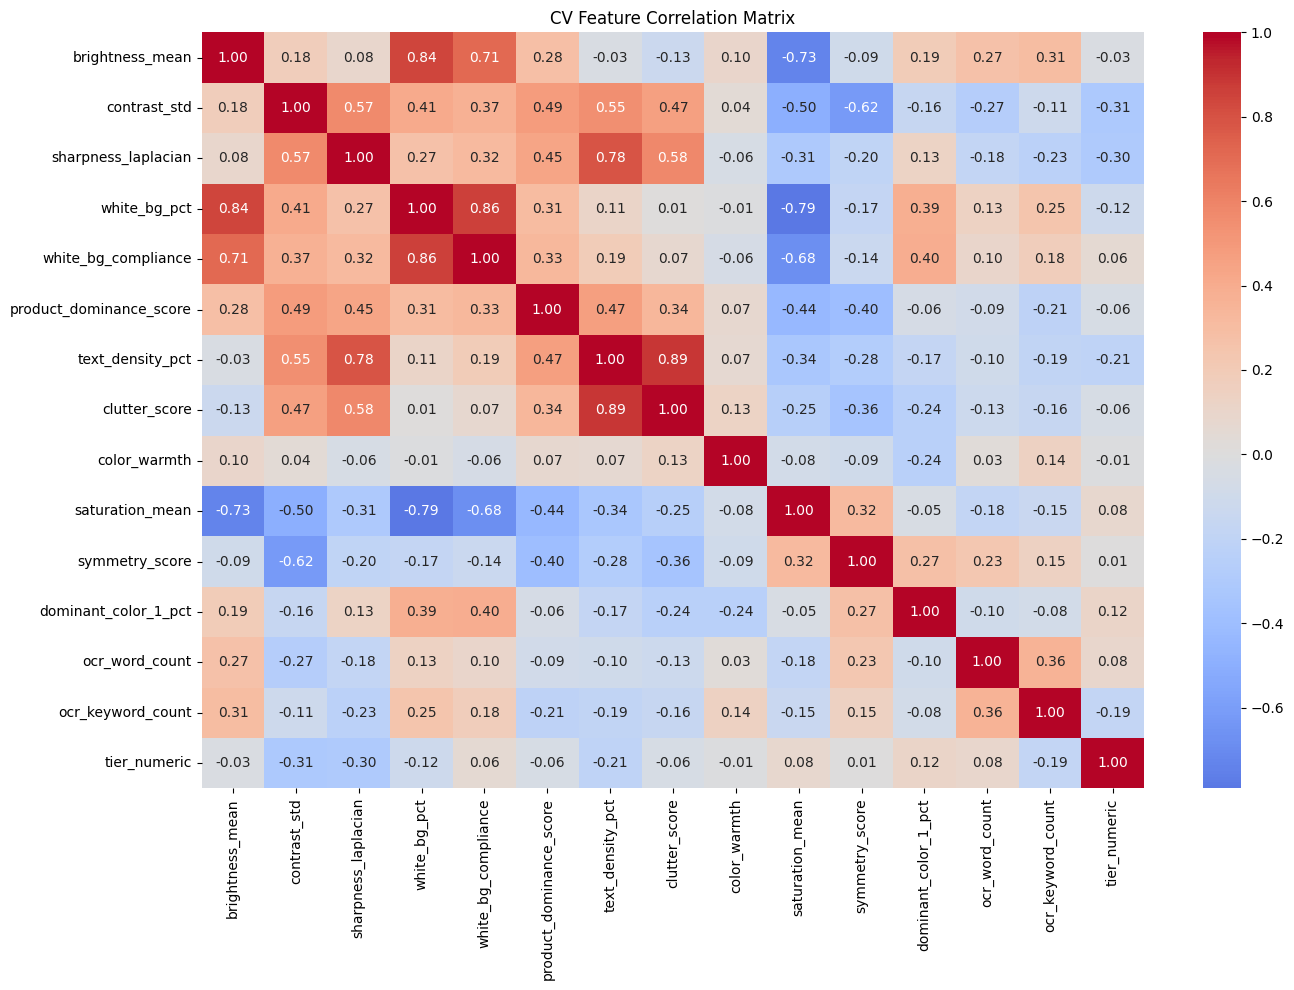

In [24]:
# 4. Correlation matrix
# Check relationships between image features and performance tier.

tier_map = {"low": 0, "medium": 1, "high": 2, "sponsor": 1}

df_clean["tier_numeric"] = df_clean["performance_tier"].map(tier_map)

corr_cols = CV_FEATURES + ["tier_numeric"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("CV Feature Correlation Matrix")
plt.tight_layout()
plt.show()

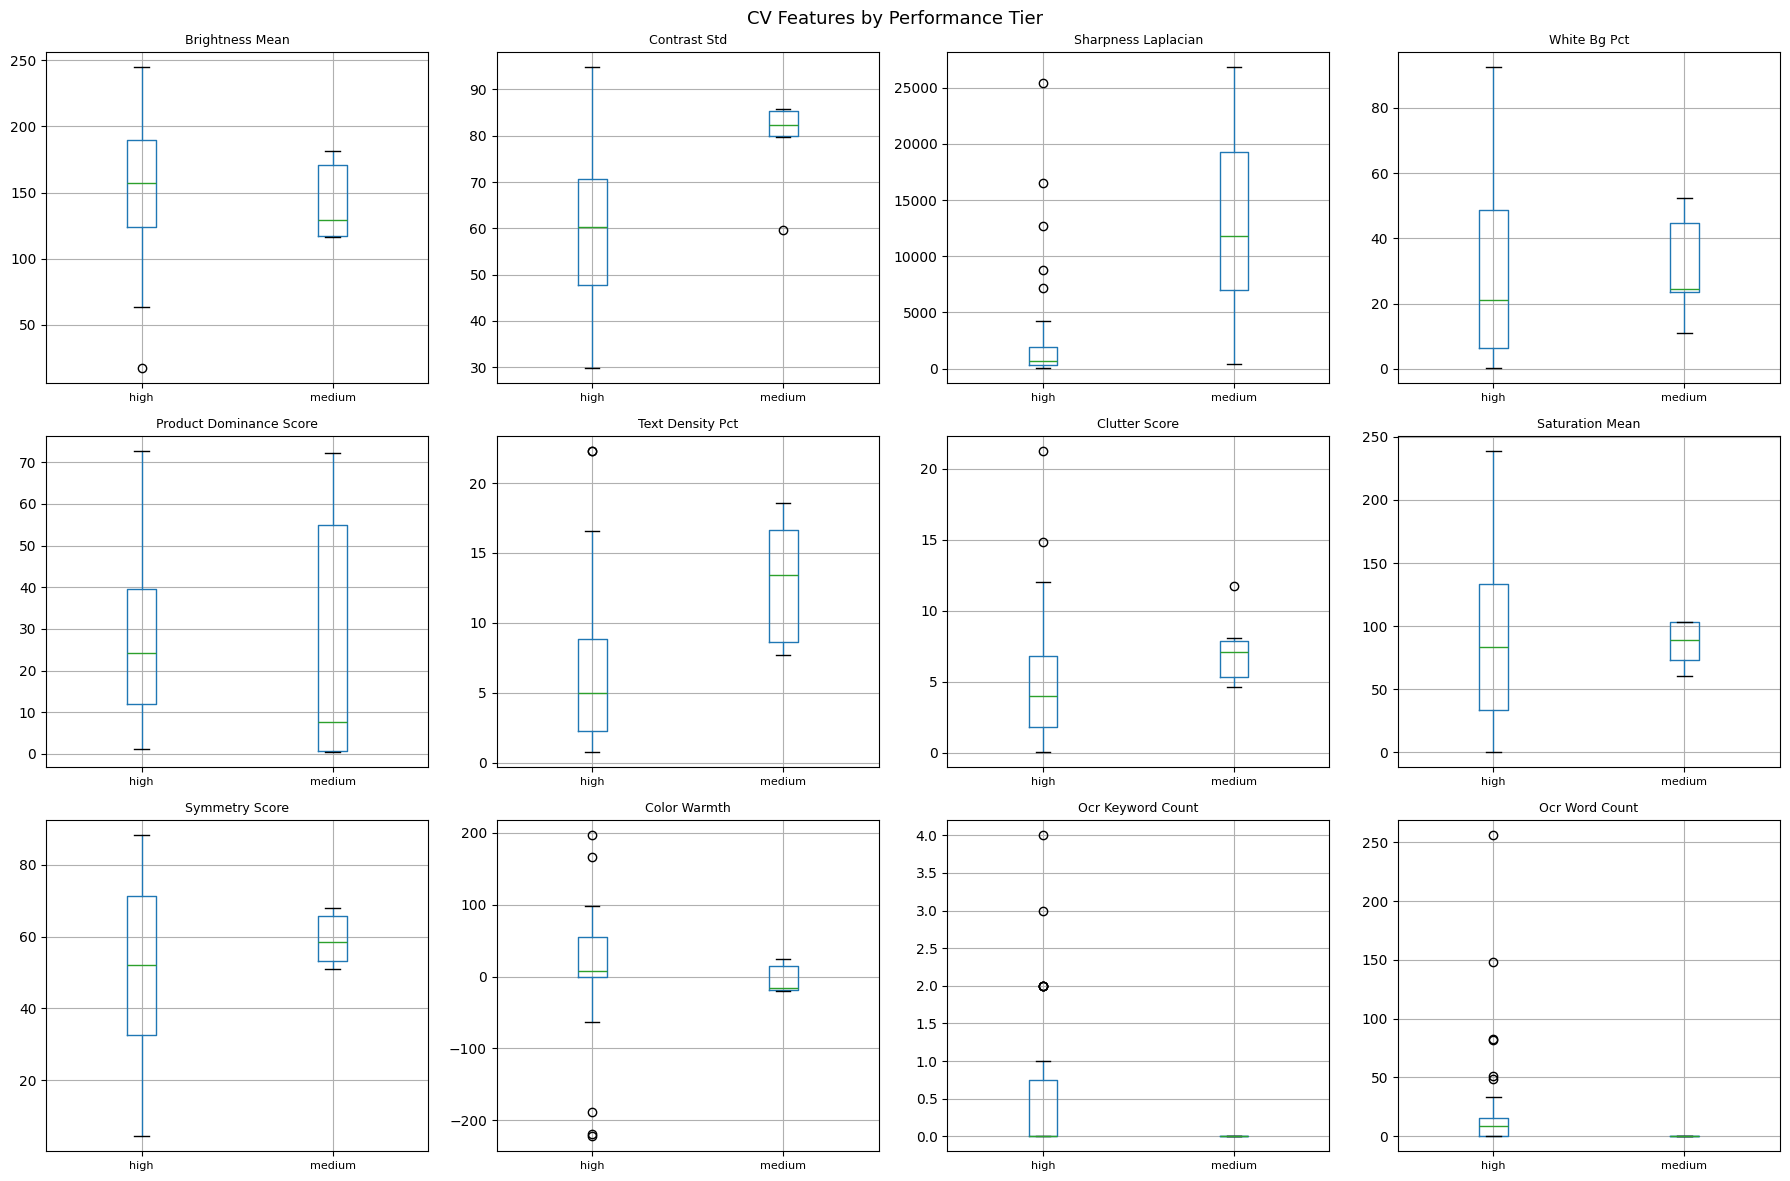

In [25]:
# 5. Boxplots by tier
# Visualize how each CV feature differs by performance tier.

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

plot_features = [
    "brightness_mean",
    "contrast_std",
    "sharpness_laplacian",
    "white_bg_pct",
    "product_dominance_score",
    "text_density_pct",
    "clutter_score",
    "saturation_mean",
    "symmetry_score",
    "color_warmth",
    "ocr_keyword_count",
    "ocr_word_count"
]

tier_order = ["low", "medium", "high"]

for ax, feat in zip(axes, plot_features):
    df_plot = df_clean[df_clean["performance_tier"].isin(tier_order)]
    df_plot.boxplot(column=feat, by="performance_tier", ax=ax)
    ax.set_title(feat.replace("_", " ").title(), fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("CV Features by Performance Tier", fontsize=13)
plt.tight_layout()
plt.show()

Explained variance: [0.344 0.212]


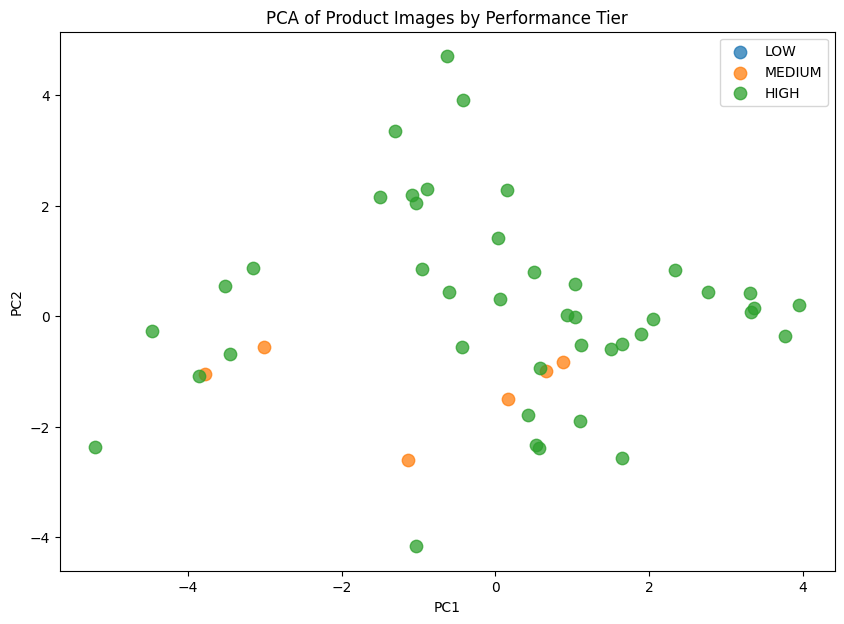

In [26]:
# 6. PCA scatter plot
# Reduce features to two components to see image-pattern clusters.

df_model = df_clean[
    df_clean["performance_tier"].isin(["low", "medium", "high"])
].copy()

X = df_model[CV_FEATURES].fillna(
    df_model[CV_FEATURES].median()
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(10, 7))

for tier in ["low", "medium", "high"]:
    mask = df_model["performance_tier"] == tier
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=tier.upper(),
        alpha=0.75,
        s=80
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Product Images by Performance Tier")
plt.legend()
plt.show()

CV accuracy (CV features): [0.875 1.    0.875] | mean = 0.917

Classification report (CV features, cross-validated):
              precision    recall  f1-score   support

        high       0.91      1.00      0.95        42
      medium       1.00      0.33      0.50         6

    accuracy                           0.92        48
   macro avg       0.96      0.67      0.73        48
weighted avg       0.92      0.92      0.90        48



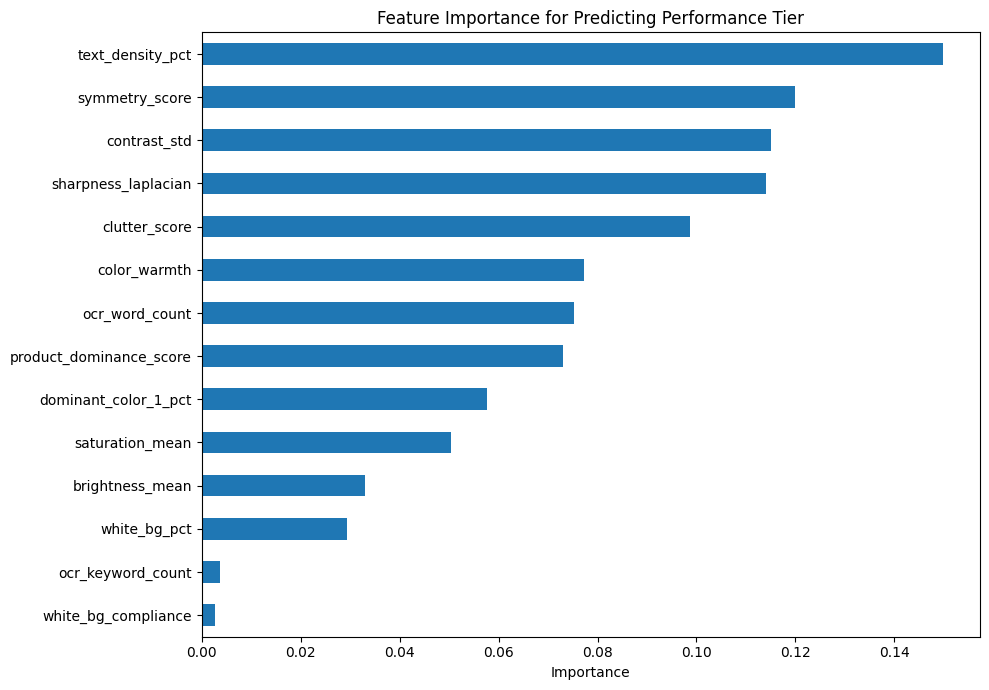

Top 3 most important features:
contrast_std        0.114987
symmetry_score      0.119999
text_density_pct    0.149795
dtype: float64


In [27]:
#7. Random Forest feature importance
# Train a model and identify the most important CV features.

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report

le = LabelEncoder()
y = le.fit_transform(df_model["performance_tier"])

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_scaled, y)

# Cross-validated accuracy is more honest than training accuracy.
# The smallest class (medium) has only 6 samples, so keep cv small.
cv_scores = cross_val_score(rf, X_scaled, y, cv=3)
print("CV accuracy (CV features):", cv_scores.round(3),
      "| mean =", cv_scores.mean().round(3))

# Per-class precision/recall shows whether the minority class is actually detected.
y_pred_cv = cross_val_predict(rf, X_scaled, y, cv=3)
print("\nClassification report (CV features, cross-validated):")
print(classification_report(y, y_pred_cv, target_names=le.classes_, zero_division=0))

importances = pd.Series(
    rf.feature_importances_,
    index=CV_FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh")
plt.title("Feature Importance for Predicting Performance Tier")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
print(importances.tail(3))

In [28]:
# 8. Rank features from most important to least important

importance_ranked = importances.sort_values(ascending=False)

top5_features = importance_ranked.head(5)

print("Top 5 Most Important Features:")
print(top5_features)

Top 5 Most Important Features:
text_density_pct       0.149795
symmetry_score         0.119999
contrast_std           0.114987
sharpness_laplacian    0.113977
clutter_score          0.098746
dtype: float64


In [29]:
# 8. Sit Stay Forever prediction
# Predict which tier the sponsor product resembles.

ssf_rows = df_clean[
    df_clean["brand"] == "Sit Stay Forever"
]

if not ssf_rows.empty:
    ssf_feats = ssf_rows[CV_FEATURES].fillna(
        df_model[CV_FEATURES].median()
    )

    ssf_scaled = scaler.transform(ssf_feats)

    ssf_pred = le.inverse_transform(
        rf.predict(ssf_scaled)
    )

    print("Sit Stay Forever predicted tier:")
    print(ssf_pred)
else:
    print("No Sit Stay Forever rows found.")

Sit Stay Forever predicted tier:
['high' 'high' 'high' 'high' 'high' 'high']


In [30]:
# 8.1 Sit Stay Forever vs High-Tier Comparison

ssf_df = df_clean[
    df_clean["brand"] == "Sit Stay Forever"
]

high_df = df_clean[
    df_clean["performance_tier"] == "high"
]

comparison_features = [
    "text_density_pct",
    "symmetry_score",
    "contrast_std",
    "sharpness_laplacian",
    "clutter_score"
]

comparison_df = pd.DataFrame({
    "Sit Stay Forever Avg": ssf_df[comparison_features].mean(),
    "High-Tier Avg": high_df[comparison_features].mean()
})

comparison_df["Difference"] = (
    comparison_df["Sit Stay Forever Avg"]
    - comparison_df["High-Tier Avg"]
)

comparison_df = comparison_df.round(3)

display(comparison_df)

,Sit Stay Forever Avg,High-Tier Avg,Difference
text_density_pct,5.034,6.329,-1.295
symmetry_score,41.945,50.870,-8.925
contrast_std,70.147,61.132,9.015
sharpness_laplacian,992.485,2526.616,-1534.131
clutter_score,3.562,4.867,-1.305


In [31]:
# 9.1 Transfer learning setup
# This cell uses a pretrained ResNet50 model from torchvision.
# If torchvision is not installed, run: pip install torch torchvision

import os
from pathlib import Path
from PIL import Image
import torch
from torch import nn
from torchvision import models, transforms
from tqdm.auto import tqdm

# Change this path if the image folder has a different name/location.
IMAGE_ROOT = Path("product_images")

# Try to automatically identify the column that contains image filenames or paths.
possible_image_cols = [
    "image_filename", "image_path", "image_file", "filename", "file_name",
    "image_name", "image", "local_path", "path"
]

image_col = None
for col in possible_image_cols:
    if col in df_clean.columns:
        image_col = col
        break

print("Detected image column:", image_col)
print("Image folder:", IMAGE_ROOT.resolve())

if image_col is None:
    print("No image path column was detected. Please set image_col manually before running ResNet extraction.")

Detected image column: image_filename
Image folder: /content/product_images


In [32]:
# 9.2 Load pretrained ResNet50 and preprocessing pipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet = models.resnet50(weights=weights)

# Remove the final classification layer so the model outputs 2048-dimensional image embeddings.
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE)
resnet.eval()

preprocess = weights.transforms()

def resolve_image_path(value, image_root=IMAGE_ROOT):
    """Return a usable local path for an image filename/path value."""
    if pd.isna(value):
        return None
    value = str(value)
    p = Path(value)
    if p.exists():
        return p
    p2 = image_root / value
    if p2.exists():
        return p2
    return None

@torch.no_grad()
def extract_resnet_embedding(image_path):
    """Extract a 2048-dimensional ResNet50 feature vector from one image."""
    img = Image.open(image_path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    embedding = resnet(x).squeeze(0).cpu().numpy()
    return embedding

Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s]


In [33]:
# 9.3 Extract ResNet embeddings for available images

if image_col is not None:
    df_resnet = df_clean[df_clean["performance_tier"].isin(["low", "medium", "high"])].copy()
    df_resnet["resolved_image_path"] = df_resnet[image_col].apply(resolve_image_path)
    df_resnet = df_resnet[df_resnet["resolved_image_path"].notna()].copy()

    print("Images available for ResNet extraction:", len(df_resnet))

    embeddings = []
    valid_indices = []

    for idx, row in tqdm(df_resnet.iterrows(), total=len(df_resnet)):
        try:
            emb = extract_resnet_embedding(row["resolved_image_path"])
            embeddings.append(emb)
            valid_indices.append(idx)
        except Exception as e:
            print(f"Skipping {row['resolved_image_path']}: {e}")

    if len(embeddings) > 0:
        X_resnet = np.vstack(embeddings)
        df_resnet = df_resnet.loc[valid_indices].copy()
        print("ResNet embedding matrix shape:", X_resnet.shape)
    else:
        X_resnet = None
        print("No embeddings were extracted. Check image paths and IMAGE_ROOT.")
else:
    X_resnet = None
    print("Skipping ResNet extraction because no image column was detected.")

Images available for ResNet extraction: 0


0it [00:00, ?it/s]

No embeddings were extracted. Check image paths and IMAGE_ROOT.


In [34]:
# 9.4 Visualize ResNet embeddings with PCA

if X_resnet is not None and len(df_resnet) >= 3:
    scaler_resnet = StandardScaler()
    X_resnet_scaled = scaler_resnet.fit_transform(X_resnet)

    pca_resnet = PCA(n_components=2, random_state=42)
    X_resnet_pca = pca_resnet.fit_transform(X_resnet_scaled)

    df_resnet["resnet_pca1"] = X_resnet_pca[:, 0]
    df_resnet["resnet_pca2"] = X_resnet_pca[:, 1]

    print("ResNet PCA explained variance:", pca_resnet.explained_variance_ratio_.round(3))

    plt.figure(figsize=(10, 7))
    for tier in ["low", "medium", "high"]:
        subset = df_resnet[df_resnet["performance_tier"] == tier]
        plt.scatter(subset["resnet_pca1"], subset["resnet_pca2"], label=tier, alpha=0.75)

    plt.xlabel("ResNet PCA Component 1")
    plt.ylabel("ResNet PCA Component 2")
    plt.title("Transfer Learning Feature Space by Performance Tier")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough ResNet embeddings to run PCA visualization.")

Not enough ResNet embeddings to run PCA visualization.


In [35]:
# 9.5 Optional: Random Forest using ResNet embeddings
# This does not fine-tune ResNet. It only tests whether pretrained deep features contain useful signals.

if X_resnet is not None and len(df_resnet["performance_tier"].unique()) >= 2:
    le_resnet = LabelEncoder()
    y_resnet = le_resnet.fit_transform(df_resnet["performance_tier"])

    rf_resnet = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
    rf_resnet.fit(X_resnet_scaled, y_resnet)

    train_acc = rf_resnet.score(X_resnet_scaled, y_resnet)
    print("Training accuracy using ResNet embeddings:", round(train_acc, 3),
          "(=1.0 just means it memorized the training data, not real performance)")

    # Cross-validated accuracy is the honest measure.
    # With 2048 features and very few samples this is expected to be low/unstable.
    cv_scores_resnet = cross_val_score(rf_resnet, X_resnet_scaled, y_resnet, cv=3)
    print("CV accuracy (ResNet features):", cv_scores_resnet.round(3),
          "| mean =", cv_scores_resnet.mean().round(3))

    # Per-class precision/recall shows whether the minority class is actually detected.
    y_pred_resnet = cross_val_predict(rf_resnet, X_resnet_scaled, y_resnet, cv=3)
    print("\nClassification report (ResNet features, cross-validated):")
    print(classification_report(y_resnet, y_pred_resnet,
                                target_names=le_resnet.classes_, zero_division=0))

    print("Classes:", list(le_resnet.classes_))
else:
    print("Skipping ResNet Random Forest because there are not enough valid classes/images.")

Skipping ResNet Random Forest because there are not enough valid classes/images.
